# Cold-weather range: resistive heater or heat pump?

In winter an electric vehicle spends battery energy on the cabin as well as on the road. A resistive heater turns 1 kWh of electricity into 1 kWh of heat. A heat pump moves heat from outside and can deliver 2 to 3 kWh of heat for the same electricity, until it gets too cold for it.

This notebook asks: **how much range does each option cost at different ambient temperatures and speeds, and how much does reusing powertrain waste heat add?**

The vehicle and the heat pump values are illustrative and generic.

## 1. Vehicle and battery

Traction power at steady speed $v$:

$$P_{trac} = \frac{1}{\eta_{dt}}\left(m g C_{rr} v + \tfrac12 \rho\, C_dA\, v^3\right)$$

Air density follows the ambient temperature: $\rho = p/(R\,T)$. Cold air is denser, so drag rises in winter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m, g = 2200.0, 9.81           # kg
Crr, CdA = 0.010, 0.75        # -, m2
eta_dt = 0.90                 # battery to wheel, motoring
E_batt = 60.0                 # kWh usable at 20 C
P_aux = 0.4                   # kW electronics, pumps, lights

def rho_air(T_C):
    return 101325/(287.05*(T_C + 273.15))

def P_trac(v_kmh, T_C):
    v = v_kmh/3.6
    return (m*g*Crr*v + 0.5*rho_air(T_C)*CdA*v**3)/eta_dt/1000   # kW

for v in (50, 80, 100, 120):
    print(f'{v:>3} km/h  traction {P_trac(v, 20):5.1f} kW at 20 C, {P_trac(v, -10):5.1f} kW at -10 C')

 50 km/h  traction   4.7 kW at 20 C,   4.8 kW at -10 C
 80 km/h  traction  10.8 kW at 20 C,  11.5 kW at -10 C
100 km/h  traction  17.4 kW at 20 C,  18.6 kW at -10 C
120 km/h  traction  26.6 kW at 20 C,  28.7 kW at -10 C


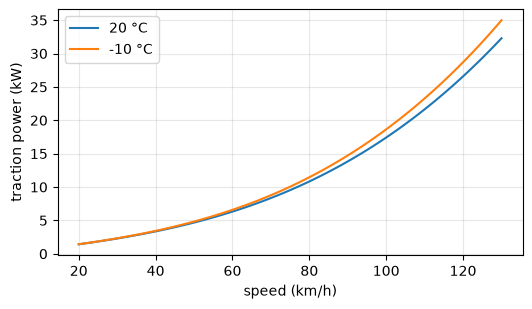

In [2]:
v = np.linspace(20, 130, 100)
plt.figure(figsize=(6, 3.2))
plt.plot(v, P_trac(v, 20), label='20 °C'); plt.plot(v, P_trac(v, -10), label='-10 °C')
plt.xlabel('speed (km/h)'); plt.ylabel('traction power (kW)'); plt.grid(alpha=.3); plt.legend(); plt.show()

**Observation.** Power grows with the cube of speed, so at 50 km/h the road load is small and any fixed heating power is a large share of it.

## 2. Cabin heat demand

Steady-state heat needed to hold the cabin at $T_{set}$, with body loss $UA$ and fresh-air ventilation $\dot m_{v}$:

$$Q_{cab} = \left(UA + \dot m_{v}c_p\right)(T_{set}-T_{amb})$$

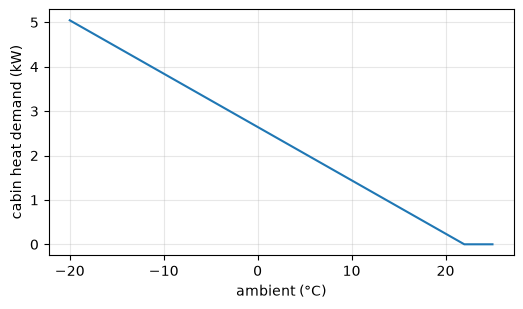

Heat demand: 2.6 kW at 0 C, 4.4 kW at -15 C


In [3]:
T_set = 22.0
UA, mdot_vent, cp_air = 90.0, 0.030, 1005.0     # W/K, kg/s, J/kg K
G_cab = UA + mdot_vent*cp_air                    # W/K

def Q_cab(T_amb):
    return np.maximum(G_cab*(T_set - T_amb), 0)/1000   # kW

T_amb_grid = np.arange(-20, 26, 1.0)
plt.figure(figsize=(6, 3.2))
plt.plot(T_amb_grid, Q_cab(T_amb_grid)); plt.xlabel('ambient (°C)'); plt.ylabel('cabin heat demand (kW)')
plt.grid(alpha=.3); plt.show()
print(f'Heat demand: {Q_cab(0):.1f} kW at 0 C, {Q_cab(-15):.1f} kW at -15 C')

**Observation.** About 2.6 kW at 0 °C and 4.4 kW at -15 °C. That is comparable to the traction power at city speed (4.7 kW at 50 km/h).

## 3. Heat pump performance

A fraction of the ideal (Carnot) heating COP, with a supply temperature $T_h$ and an evaporator that sits $\Delta T_{ev}$ below ambient:

$$COP = \eta_{c}\,\frac{T_h}{T_h - T_{ev}}, \qquad T_{ev}=T_{amb}-\Delta T_{ev}$$

Below a cut-out temperature the pump is off and the resistive heater takes over.

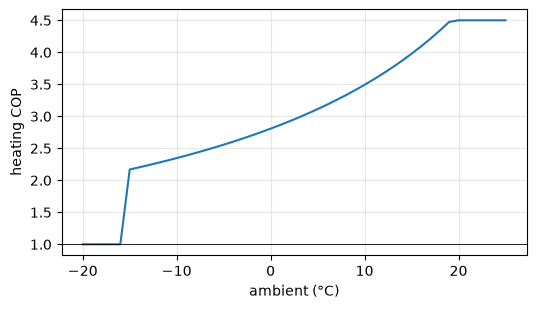

COP 3.49 at 10 C, 2.81 at 0 C, 2.35 at -10 C


In [4]:
eta_c, T_h, dT_ev = 0.45, 45.0, 6.0
T_cut = -15.0

def COP_hp(T_amb):
    T_ev = T_amb - dT_ev
    cop = eta_c*(T_h + 273.15)/(T_h - T_ev)
    cop = np.clip(cop, 1.0, 4.5)
    return np.where(T_amb >= T_cut, cop, 1.0)

plt.figure(figsize=(6, 3.2))
plt.plot(T_amb_grid, COP_hp(T_amb_grid)); plt.axhline(1, color='k', lw=.6)
plt.xlabel('ambient (°C)'); plt.ylabel('heating COP'); plt.grid(alpha=.3); plt.show()
print(f'COP {COP_hp(np.array([10.0]))[0]:.2f} at 10 C, {COP_hp(np.array([0.0]))[0]:.2f} at 0 C, {COP_hp(np.array([-10.0]))[0]:.2f} at -10 C')

**Observation.** The COP is about 3.5 at 10 °C, 2.8 at 0 °C and 2.2 at -15 °C. The gain over a resistive heater fades as it gets colder, and below the cut-out it is gone.

## 4. Range

Battery capacity also falls in the cold. Usable energy is $E(T)=E_0\,[1-k(20-T)]$ below 20 °C, with $k=0.4\%$ per K here.

Electrical power drawn from the battery: $P = P_{trac} + P_{aux} + Q_{cab}/COP$. Range $= E(T)\,v/P$.

Heat pump with waste heat: a share $f_w$ of the traction losses is recovered into the cabin loop and reduces $Q_{cab}$.

In [5]:
k_cap = 0.004
def E_usable(T_amb):
    return E_batt*(1 - k_cap*np.maximum(20 - T_amb, 0))

f_w = 0.5                       # share of drivetrain loss recovered
def P_waste(v_kmh, T_C):
    return f_w*(1 - eta_dt)*P_trac(v_kmh, T_C)*eta_dt*0.9   # kW, motor and inverter loss share

def rng(v_kmh, T_amb, mode):
    Pt = P_trac(v_kmh, T_amb) + P_aux
    q = Q_cab(T_amb)
    if mode == 'resistive':
        P = Pt + q
    elif mode == 'heat pump':
        P = Pt + q/COP_hp(T_amb)
    elif mode == 'heat pump + waste heat':
        P = Pt + np.maximum(q - P_waste(v_kmh, T_amb), 0)/COP_hp(T_amb)
    else:                                   # no heating, reference
        P = Pt
    return E_usable(T_amb)*v_kmh/P

for T in (20, 0, -15):
    print(f'{T:>4} C at 60 km/h:', {md: round(float(rng(60, np.array([float(T)]), md)[0])) for md in ('none', 'resistive', 'heat pump', 'heat pump + waste heat')})

  20 C at 60 km/h: {'none': 536, 'resistive': 517, 'heat pump': 532, 'heat pump + waste heat': 536}
   0 C at 60 km/h: {'none': 481, 'resistive': 347, 'heat pump': 423, 'heat pump + waste heat': 428}
 -15 C at 60 km/h: {'none': 440, 'resistive': 270, 'heat pump': 341, 'heat pump + waste heat': 346}


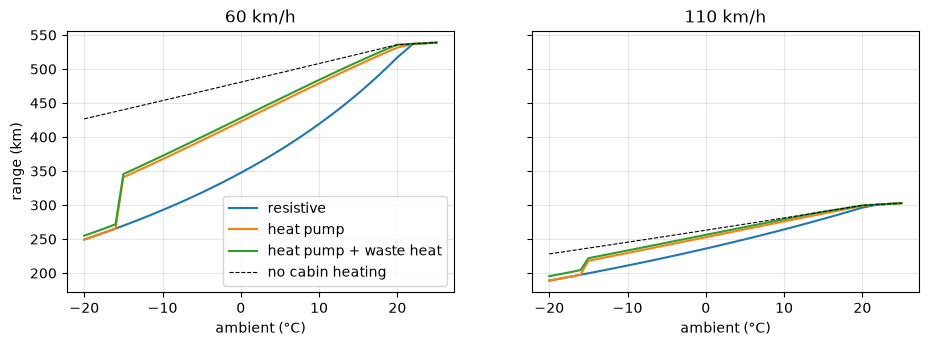

In [6]:
modes = ['resistive', 'heat pump', 'heat pump + waste heat']
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, v in zip(axs, (60, 110)):
    for md in modes:
        ax.plot(T_amb_grid, rng(v, T_amb_grid, md), label=md)
    ax.plot(T_amb_grid, rng(v, T_amb_grid, 'none'), 'k--', lw=.8, label='no cabin heating')
    ax.set_title(f'{v} km/h'); ax.set_xlabel('ambient (°C)'); ax.grid(alpha=.3)
axs[0].set_ylabel('range (km)'); axs[0].legend(); plt.show()

**Observation.** At 60 km/h the resistive heater costs about 130 km of range at 0 °C (481 km with no heating against 347 km); the heat pump recovers about 75 km of that. At 110 km/h the road load dominates and the three lines are close together.

## 5. Range gain from the heat pump

Gain over the resistive heater, in km, for a few ambient temperatures and speeds.

In [7]:
Ts = np.array([10.0, 0.0, -10.0, -20.0])
print('speed  ambient  resistive  heat pump  +waste   gain(hp)  gain(hp+waste)')
rows = []
for v in (50, 80, 110):
    for T in Ts:
        r = float(rng(v, np.array([T]), 'resistive')[0]); h = float(rng(v, np.array([T]), 'heat pump')[0]); w = float(rng(v, np.array([T]), 'heat pump + waste heat')[0])
        rows.append((v, T, r, h, w))
        print(f'{v:>4}   {T:>6.0f}   {r:8.0f}   {h:8.0f}   {w:6.0f}   {h-r:6.0f} km   {w-r:6.0f} km')

speed  ambient  resistive  heat pump  +waste   gain(hp)  gain(hp+waste)
  50       10        439        520      526       82 km       87 km
  50        0        353        451      457       98 km      103 km
  50      -10        291        384      389       94 km       98 km
  50      -20        244        244      249        0 km        5 km
  80       10        358        389      393       31 km       35 km
  80        0        309        351      356       42 km       46 km
  80      -10        269        313      318       44 km       49 km
  80      -20        235        235      242        0 km        7 km
 110       10        264        276      279       12 km       15 km
 110        0        236        253      256       17 km       20 km
 110      -10        211        229      233       18 km       22 km
 110      -20        189        189      195        0 km        6 km


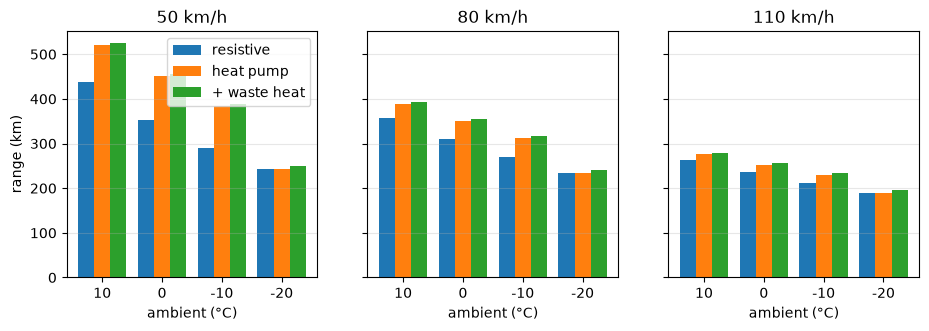

In [8]:
labels = [f'{int(T)}' for T in Ts]
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, v in zip(axs, (50, 80, 110)):
    sel = [r for r in rows if r[0] == v]
    x = np.arange(len(sel))
    ax.bar(x-0.27, [r[2] for r in sel], 0.27, label='resistive')
    ax.bar(x, [r[3] for r in sel], 0.27, label='heat pump')
    ax.bar(x+0.27, [r[4] for r in sel], 0.27, label='+ waste heat')
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_title(f'{v} km/h'); ax.set_xlabel('ambient (°C)'); ax.grid(alpha=.3, axis='y')
axs[0].set_ylabel('range (km)'); axs[0].legend(); plt.show()

**Observation.** The heat pump gives the biggest gain at slow speed and around 0 to -10 °C. At -20 °C it is switched out and only the waste-heat share remains.

## 6. How sensitive is this to the assumptions?

The heat pump quality ($\eta_c$) and the cabin conductance are the values I trust least. Vary each by ±25 % and look at the range gain at 0 °C and 60 km/h.

In [9]:
base_eta, base_G = eta_c, G_cab
res = {}
for name in ('eta_c', 'G_cab'):
    for f in (0.75, 1.0, 1.25):
        eta_c, G_cab = base_eta, base_G
        if name == 'eta_c': eta_c = base_eta*f
        else: G_cab = base_G*f
        r = float(rng(60, np.array([0.0]), 'resistive')[0]); h = float(rng(60, np.array([0.0]), 'heat pump')[0])
        res[(name, f)] = h - r
eta_c, G_cab = base_eta, base_G
for k, val in res.items():
    print(f'{k[0]:>6} x{k[1]:.2f}: gain {val:5.1f} km')

 eta_c x0.75: gain  59.2 km
 eta_c x1.00: gain  75.5 km
 eta_c x1.25: gain  85.9 km
 G_cab x0.75: gain  62.7 km
 G_cab x1.00: gain  75.5 km
 G_cab x1.25: gain  85.7 km


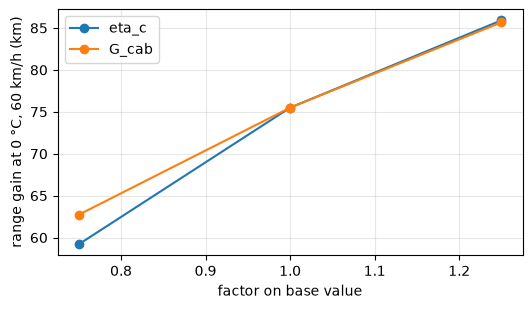

In [10]:
plt.figure(figsize=(6, 3.2))
for name in ('eta_c', 'G_cab'):
    plt.plot([0.75, 1, 1.25], [res[(name, f)] for f in (0.75, 1.0, 1.25)], 'o-', label=name)
plt.xlabel('factor on base value'); plt.ylabel('range gain at 0 °C, 60 km/h (km)'); plt.grid(alpha=.3); plt.legend(); plt.show()

**Observation.** Both matter about equally. A poorer heat pump or a leakier cabin changes the answer by tens of kilometres, so these two need test data before the numbers are used for anything real.

## What this does and does not say

- The heat pump earns most in mild cold at low speed; that is the city winter case.
- Waste heat adds a modest amount and matters most when the heat pump is weak or off.
- Not included: cabin warm-up transient, battery heating, defrost cycles, humidity, and the heat pump's own limit on compressor speed. These are the natural next steps.
- Steady speed with no stops gives longer ranges than real driving, so read the differences between options, not the absolute km.
- All values are illustrative. They show how the quantities relate; they are not design data.